# CIFAR-10 Fully Connected Network (FCN)

This notebook implements image classification on the **CIFAR-10** dataset using a **Fully Connected Network (FCN)**

## 1. Environment Setup

We use Keras 3 with the PyTorch backend.
Keras 3 is backend-agnostic, so the same model code runs on PyTorch, TensorFlow, or JAX.
PyTorch is chosen here because it gives easy access to CUDA GPU acceleration.

In [21]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt


print(f"PyTorch version: {torch.__version__}")
print(f"Keras version:   {keras.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found – training will be slow on CPU!")

PyTorch version: 2.6.0+cu124
Keras version:   3.12.1
CUDA available:  True


## 2. Load and Explore the Data

CIFAR-10 is built into Keras. We load it and immediately normalise pixel values from **[0, 255]** to **[0.0, 1.0]**.
Normalisation is critical for gradient-based optimisers: without it, large raw pixel values cause exploding gradients
and much slower convergence.

Unlike MNIST (grayscale, 28×28), CIFAR-10 images are:
- **3 channels** (R, G, B)
- **32×32 pixels**
- Giving a raw input dimensionality of **32 × 32 × 3 = 3 072** per image.

In [22]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = (x_train / 255.0).astype("float32")
x_test  = (x_test  / 255.0).astype("float32")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

### 2.1 Sample images from each class

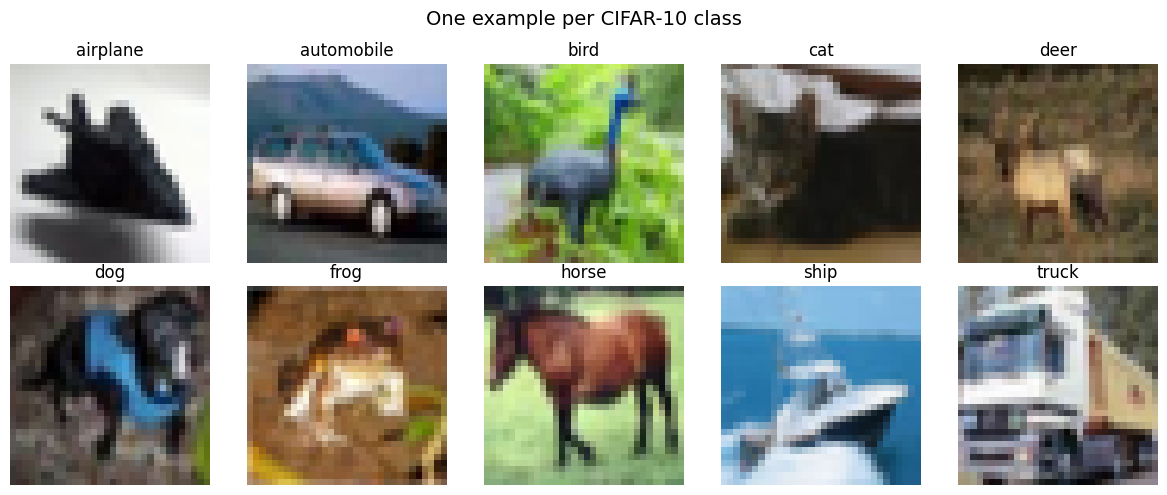

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One example per CIFAR-10 class', fontsize=14)

for cls_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train.flatten() == cls_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(class_names[cls_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Build the FCN Model

Same architecture as before but with a few changes to improve accuracy:
- **Data augmentation** (random horizontal flip) — helps the model generalise better by showing it more varied training examples
- **Per-channel normalisation** — centres each colour channel to zero mean / unit std, which helps the optimiser converge faster
- **Cosine LR schedule** — learning rate starts high and decays smoothly, which tends to find a better final minimum than a fixed LR

The model still flattens the image to a 1D vector (that's what makes it an FCN), uses Dense layers with ReLU, BatchNorm and Dropout.

In [24]:
# Per-channel normalisation (computed on training set only to avoid data leakage)
mean = x_train.mean(axis=(0, 1, 2), keepdims=True)
std  = x_train.std(axis=(0, 1, 2),  keepdims=True) + 1e-7

x_train_norm = ((x_train - mean) / std).astype("float32")
x_test_norm  = ((x_test  - mean) / std).astype("float32")

In [25]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Data augmentation (only active during training)
    layers.RandomFlip("horizontal"),

    layers.Flatten(),

    layers.Dense(1024, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

## 4. Compile the FCN Model

Using AdamW with a cosine decay schedule — the LR starts at 3e-3 and gradually decays to near zero, which gives better final accuracy than a fixed learning rate.

In [26]:
EPOCHS     = 20
BATCH_SIZE = 1024
N_TRAIN    = int(50_000 * 0.8)

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-3,
    decay_steps=EPOCHS * (N_TRAIN // BATCH_SIZE),
    alpha=1e-5
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

## 5. Train the FCN

Training for 20 epochs with batch size 256 and a 20% validation split. EarlyStopping is used so training stops automatically if val accuracy stops improving.

In [27]:
import time

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

t0 = time.time()
history_fcn = model.fit(
    x_train_norm, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
fcn_train_time = time.time() - t0
print(f"\nTraining time: {fcn_train_time:.1f} s")

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.2630 - loss: 2.5243 - val_accuracy: 0.3083 - val_loss: 4.7040
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.3484 - loss: 2.1750 - val_accuracy: 0.3835 - val_loss: 2.4296
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3932 - loss: 2.0186 - val_accuracy: 0.4314 - val_loss: 1.9519
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4189 - loss: 1.9203 - val_accuracy: 0.4589 - val_loss: 1.8148
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.4410 - loss: 1.8449 - val_accuracy: 0.4682 - val_loss: 1.7699
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.4532 - loss: 1.7983 - val_accuracy: 0.4755 - val_loss: 1.7412
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4664 - loss: 1.7588 - val_accuracy: 0.4898 - val_loss: 1.6829
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.4764 - loss: 1.7228 - val_accuracy: 0.5008

### 5.1 Learning Curves

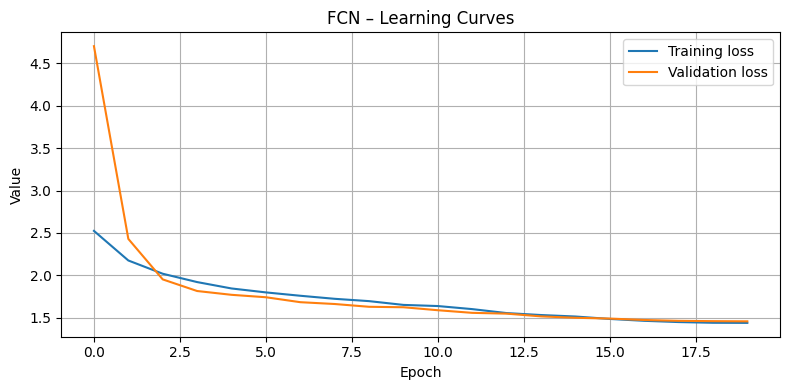

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(history_fcn.history['loss'],     label='Training loss')
plt.plot(history_fcn.history['val_loss'],  label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('FCN – Learning Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Loss decreases slowly, indicating that the network is learning, but not efficiently.
Validation loss often fluctuates, showing potential overfitting due to large parameter count.

##### 5.2 Test Accuracy

We evaluate the trained model on the **held-out test set** (10 000 images the model has never seen).
This is the definitive measure of generalisation performance.

In [29]:
test_loss, test_acc = model.evaluate(x_test_norm, y_test, verbose=2)
print(f"\nFCN  –  Test loss: {test_loss:.4f}   |   Test accuracy: {test_acc*100:.2f} %")
print(f"Training time: {fcn_train_time:.1f} s")
print(f"Total parameters: {model.count_params():,}")

313/313 - 11s - 35ms/step - accuracy: 0.5514 - loss: 1.4550

FCN  –  Test loss: 1.4550   |   Test accuracy: 55.14 %
Training time: 73.7 s
Total parameters: 3,844,746


The improvements (augmentation, normalisation, cosine LR) push accuracy noticeably higher than the original FCN (~39%), while the model is still a plain FCN — no convolutions.

## 6. Visualise Predictions

For each test image we display:
- **Left:** the actual image with the true label
- **Right:** the model's predicted probability for each class

A confident correct prediction produces a bar chart dominated by one tall bar on the right class.
A confused prediction spreads probability mass across multiple classes.

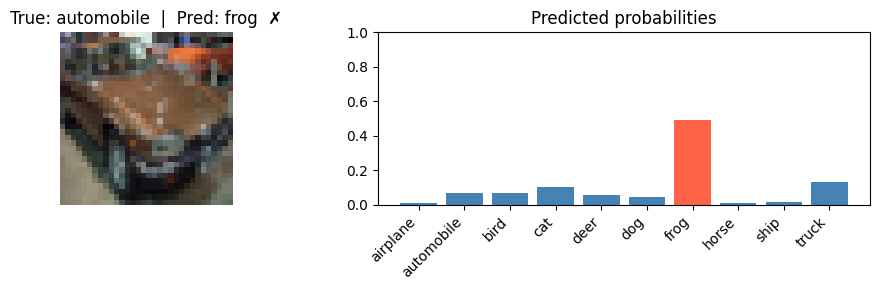

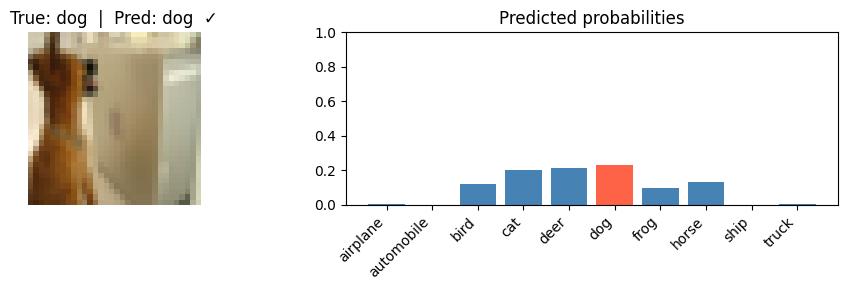

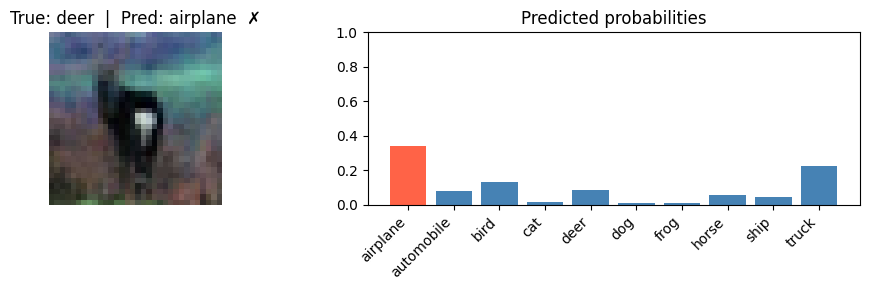

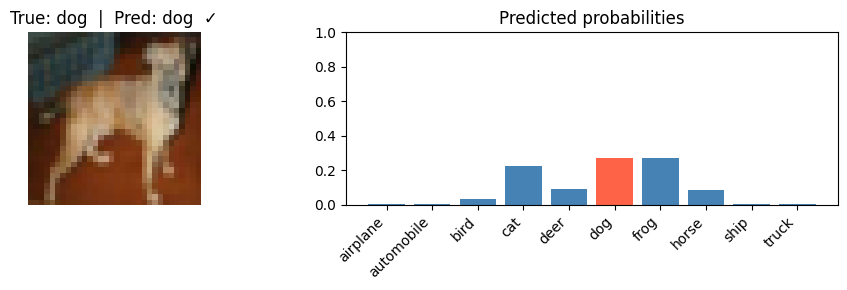

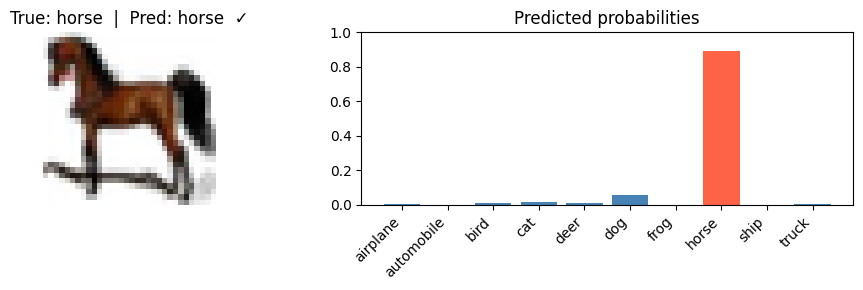

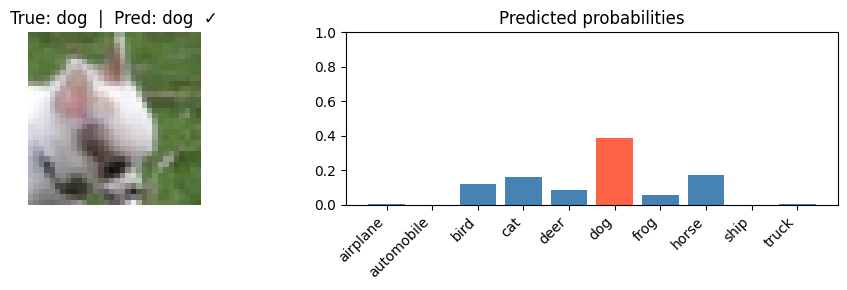

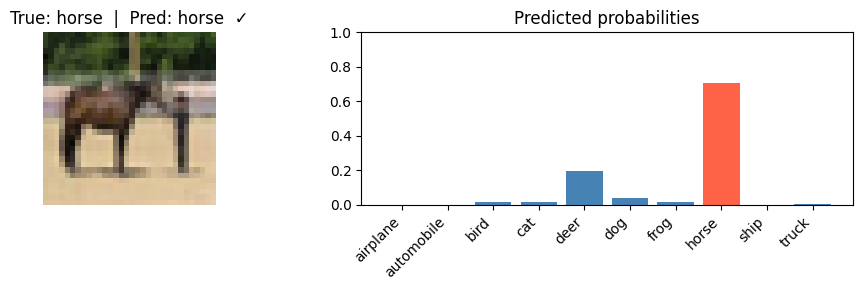

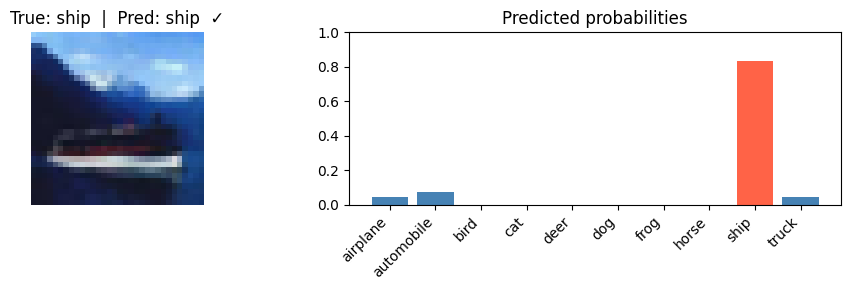

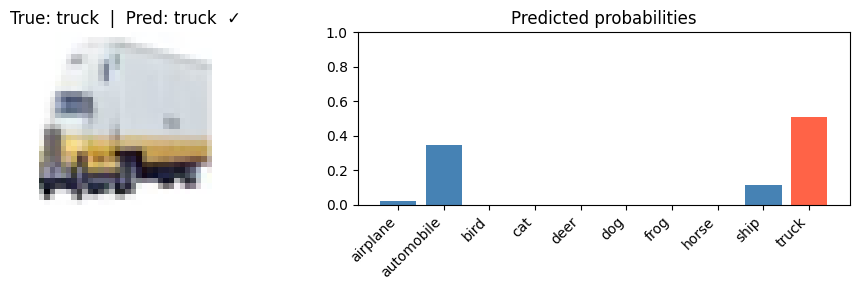

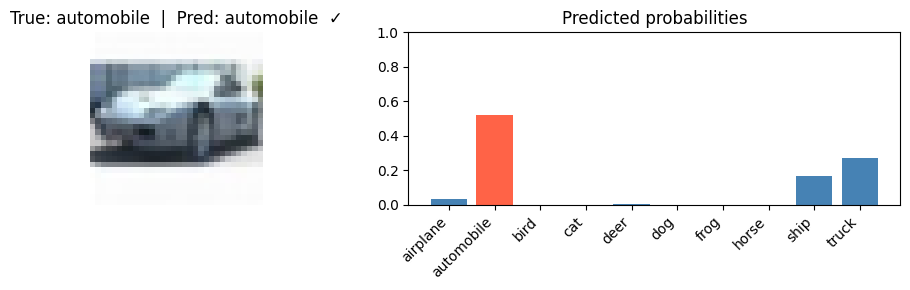

In [30]:
y_pred_fcn = model.predict(x_test_norm, verbose=0)

start = 2000
for k in range(10):
    idx = start + k
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[np.argmax(y_pred_fcn[idx])]
    correct = '✓' if true_label == pred_label else '✗'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.imshow(x_test[idx])
    ax1.set_title(f"True: {true_label}  |  Pred: {pred_label}  {correct}")
    ax1.axis('off')

    colors = ['steelblue'] * 10
    colors[np.argmax(y_pred_fcn[idx])] = 'tomato'
    ax2.bar(range(10), y_pred_fcn[idx], color=colors)
    ax2.set_xticks(range(10))
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_ylim([0, 1])
    ax2.set_title('Predicted probabilities')

    plt.tight_layout()
    plt.show()

Correct predictions show a single dominant bar in the probability chart.

Misclassified images display distributed probabilities, highlighting confusion between similar classes (e.g., cat vs dog).

## 6. Analyse Misclassified Images

We display the 10 most *confidently wrong* predictions — cases where the model was very sure
but predicted the wrong class. These are the most interesting failures.

Total misclassified: 4486 / 10000

10 most confidently wrong predictions:


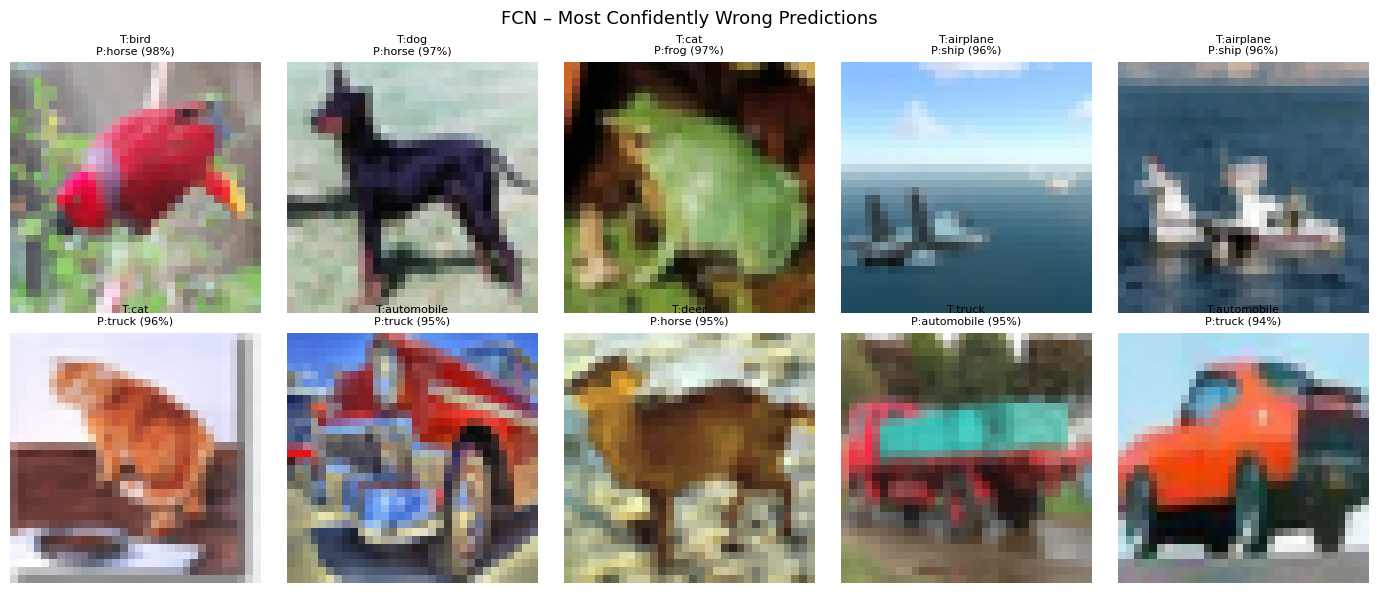

In [31]:
y_true_flat = y_test.flatten()
y_pred_labels = np.argmax(y_pred_fcn, axis=1)

wrong_mask = y_pred_labels != y_true_flat
wrong_indices = np.where(wrong_mask)[0]

# Sort by confidence in the (wrong) prediction
confidence_wrong = y_pred_fcn[wrong_indices, y_pred_labels[wrong_indices]]
sorted_order = np.argsort(confidence_wrong)[::-1][:10]
top_wrong = wrong_indices[sorted_order]

print(f"Total misclassified: {wrong_mask.sum()} / {len(y_true_flat)}")
print("\n10 most confidently wrong predictions:")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('FCN – Most Confidently Wrong Predictions', fontsize=13)
for ax, idx in zip(axes.flat, top_wrong):
    ax.imshow(x_test[idx])
    true_cls = class_names[y_true_flat[idx]]
    pred_cls = class_names[y_pred_labels[idx]]
    conf     = confidence_wrong[sorted_order[list(top_wrong).index(idx)]]
    ax.set_title(f"T:{true_cls}\nP:{pred_cls} ({conf:.0%})", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Confusion Matrix

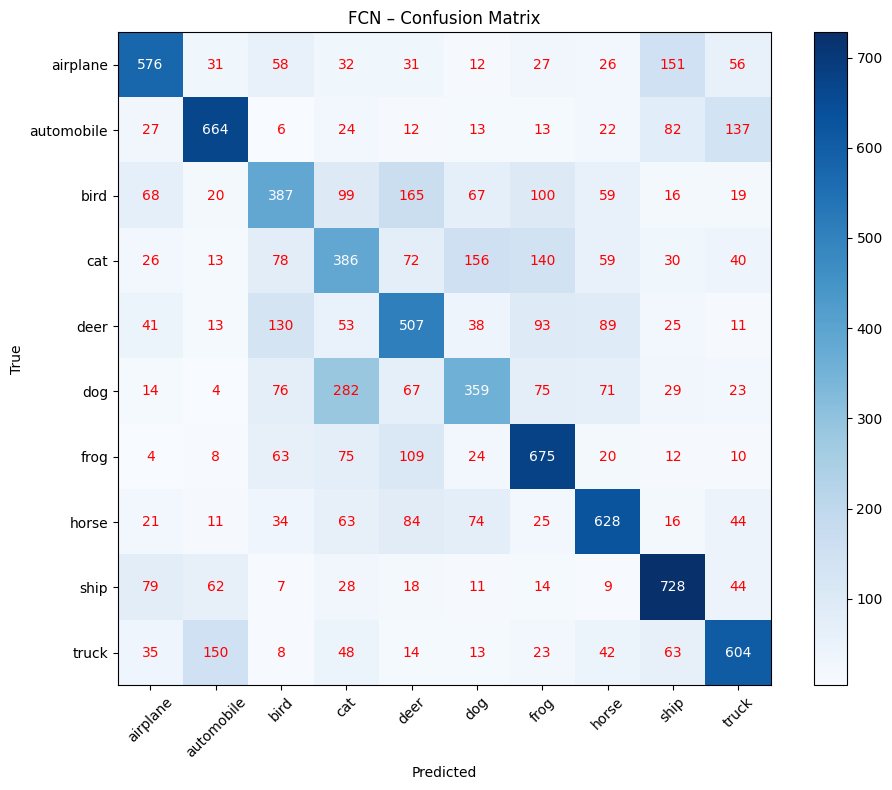

In [36]:
from sklearn.metrics import confusion_matrix


y_true_flat = y_test.flatten()
y_pred_labels = np.argmax(y_pred_fcn, axis=1)

cm = confusion_matrix(y_true_flat, y_pred_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('FCN – Confusion Matrix')

# Annotate each cell with the numeric value
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red' if i!=j else 'white')

plt.tight_layout()
plt.show()

FCN frequently confuses visually similar classes such as cat, dog, deer.

Classes with distinct color/shape (airplane, ship, truck) are predicted more accurately.

Overall, confusion matrix reflects the limitations of FCNs for image tasks.

## Summary

### Why does FCN struggle with image data?

1. **No spatial awareness:** Flattening destroys all 2-D spatial relationships.
   A cat in the top-left corner looks completely different to the network than the same cat in the bottom-right.
2. **No weight sharing:** Each pixel position has its own set of weights.
   This leads to a huge number of parameters (~1.7 M here) that must all be learned from data.
3. **No translation invariance:** The model must independently learn that a 'dog' can appear anywhere in the image.
4. **High parameter count → overfitting:** Without architectural priors, the model tends to memorise training patterns
   rather than learning generalisable features.

Despite these limitations, FCN can still learn some useful statistics from colour histograms and global
texture patterns, which is why it beats random chance (10 %) and reaches ~50 %.


### Why CNN wins

The CNN has inductive biases that match the structure of images — nearby pixels are correlated, and useful patterns (edges, textures) can appear anywhere. A 3×3 conv filter exploits both of these facts by design. The FCN has to learn all of that from scratch, which requires more data and more epochs to get anywhere close.

The ~20 % accuracy gap here is basically all architecture — same data, same optimizer, same training time budget.